In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import random
import mlflow

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, brier_score_loss, auc
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from mlflow.tracking import MlflowClient


import xgboost as xgb

from itertools import product

pd.set_option('display.max_rows', 1000)

In [2]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("btc_timezone_analysis_model_training")


<Experiment: artifact_location='/home/matej/btc_timezone_analysis/model_training/mlruns_artifacts/1', creation_time=1788068935670, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788068935670, lifecycle_stage='active', name='btc_timezone_analysis_model_training', tags={}, trace_location=None, workspace='default'>

mlflow server code mlflow server --backend-store-uri sqlite:///backend.db --default-artifact-root ./mlruns_artifacts

# Functions

In [3]:
# Definition of function which produce classification report and confusion matrix for train and also val set 
def class_report(y_train, y_train_pred, y_val, y_val_pred, target_name):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), 
                             gridspec_kw={'height_ratios': [0.5, 1.5]})
    
    # Train classification report
    axes[0, 0].text(-0.2, 0.4, classification_report(y_train, y_train_pred, target_names=["America", "Central_Asia", "East_Asia_Pac", "Euro_Africa"]), 
                    fontsize=13, family='monospace', va='center')
    axes[0, 0].set_title("Classification Report (Train)", fontsize=14, fontweight='bold')
    axes[0, 0].axis('off') 
    
    # Val classification report
    axes[0, 1].text(-0.2, 0.4, classification_report(y_val, y_val_pred, target_names=["America", "Central_Asia", "East_Asia_Pac", "Euro_Africa"]), 
                    fontsize=13, family='monospace', va='center')
    axes[0, 1].set_title("Classification Report (Val)", fontsize=14, fontweight='bold')
    axes[0, 1].axis('off') 
    
    # Train Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_train, y_train_pred, 
        ax=axes[1, 0], cmap='Blues', normalize='true',
        labels=target_name
    )
    axes[1, 0].set_title("Training Confusion Matrix (Normalized)")
    axes[1, 0].tick_params(axis='x', rotation=90)
    
    # Val Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_val_pred, 
        ax=axes[1, 1], cmap='Greens', normalize='true',
        labels=target_name
    )
    axes[1, 1].set_title("Validation Confusion Matrix (Normalized)")
    axes[1, 1].tick_params(axis='x', rotation=90)
    
    plt.savefig("./plots/class_report", dpi=300, bbox_inches='tight')
    plt.close()

In [4]:
# Definition of function which produce calibration curve per each region for train and also val set 
def calibration_curve_classes(y_train, y_train_proba, y_train_pred, y_val, y_val_proba, y_val_pred, colors, labels):
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    
    for j, a in zip(range(2), ["train", "val"]):
        ax[j].plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
        ax[j].plot([0.75, 0.75], [-0.05, 1.05], "--", color="#C0C0C0")
        for l, c in zip(labels, colors):
            proba = locals()[f"y_{a}_proba"]
            pred  = locals()[f"y_{a}_pred"]
            true  = locals()[f"y_{a}"]
        
            subset = (true == l)
            
            confidences = np.max(proba[subset], axis=1)
            accuracies = (pred[subset] == true[subset]).astype(int)
            n_bins = 5
            percentiles = np.linspace(0.0, 1.0, n_bins + 1)
            bins = np.quantile(confidences, percentiles)
            bin_indices = np.digitize(confidences, bins) - 1
            bin_indices[bin_indices == n_bins] = n_bins - 1
            
            bin_accuracies = []
            bin_confidences = []
            bin_percentages = []
            
            for i in range(n_bins):
                mask = (bin_indices == i)
                if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
                    bin_accuracies.append(np.mean(accuracies[mask]))
                    bin_confidences.append(np.mean(confidences[mask]))
                    bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
        
            ax[j].plot(bin_confidences, bin_accuracies, marker='o', linestyle='-', color=c, label=l)
        
        ax[j].set_xlabel("Confidence")
        ax[j].set_ylabel("True Accuracy")
        ax[j].set_title(f"Calibration Graph per each class on {a} set")
        ax[j].legend(loc="upper left")
        ax[j].grid(True, alpha=0.5)
        ax[j].set_xlim([-0.05, 1.05])
        ax[j].set_ylim([-0.05, 1.05])
        
    plt.savefig("./plots/calibration_graph.png", dpi=300, bbox_inches='tight')
    plt.close()

In [5]:
def get_mlflow_confidence_metrics(
    y_val_true, y_val_pred, y_val_prob, 
    y_train_true, y_train_pred, y_train_prob, 
    target_names
):
    metrics = {}

    metrics['train_brier_score'] = float(brier_score_loss(label_binarize(y_train_true, classes=target_names), y_train_prob))
    metrics['val_brier_score'] = float(brier_score_loss(label_binarize(y_val_true, classes=target_names), y_val_prob))
    metrics['train_accuracy'] = float(accuracy_score(y_train_true, y_train_pred))
    metrics['val_accuracy'] = float(accuracy_score(y_val_true, y_val_pred))
    metrics['samples'] = len(y_val_true)

    
    # 3. Confidence Thresholds (Calculated on the Validation set)
    y_val_true = np.array(y_val_true)
    y_val_pred = np.array(y_val_pred)
    confidences = np.max(np.array(y_val_prob), axis=1)
    
    thresholds = [0.50, 0.60, 0.70, 0.80, 0.90]
    
    for t in thresholds:
        t_str = f"val_conf_{int(t * 100)}"
        mask = (confidences >= t)
        n_samples = int(np.sum(mask))
        
        metrics[f"{t_str}_samples"] = n_samples
        if n_samples > 0:
            metrics[f"{t_str}_accuracy"] = float(accuracy_score(y_val_true[mask], y_val_pred[mask]))
        else:
            metrics[f"{t_str}_accuracy"] = 0.0
            
    return metrics

In [6]:
def calculate_aurc(y_true, y_prob, y_pred):
    """
    Calculates the Area Under the Risk-Coverage Curve (AURC).
    """
    # 1. Convert to pure NumPy arrays to avoid Pandas KeyErrors
    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    
    # 2. Extract the model's confidence
    confidences = np.max(y_prob, axis=1)
    
    # 3. Determine which predictions are incorrect (Error = 1, Correct = 0)
    # By using y_pred directly, this safely compares strings to strings or ints to ints!
    errors = (y_true_np != y_pred_np).astype(int)
    
    # 4. Sort the samples by confidence in descending order
    sorted_indices = np.argsort(-confidences)
    sorted_errors = errors[sorted_indices]
    
    # 5. Calculate Coverage (x-axis)
    n_samples = len(y_true_np)
    coverages = np.arange(1, n_samples + 1) / n_samples
    
    # 6. Calculate Risk (y-axis): The cumulative mean of errors
    cumulative_errors = np.cumsum(sorted_errors)
    risks = cumulative_errors / np.arange(1, n_samples + 1)
    
    # 7. Add the starting point (0 coverage) to anchor the graph
    coverages = np.insert(coverages, 0, 0.0)
    risks = np.insert(risks, 0, risks[0]) 
    
    
    return coverages, risks

In [7]:
def plot_risk_coverage_curve(y_train, y_train_proba, y_train_pred, y_val, y_val_proba, y_val_pred):
    """Plots the Risk-Coverage curves for Train and Val sets side-by-side."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bundle the datasets to iterate through them easily
    datasets = [
        ("Train", y_train, y_train_proba, y_train_pred, axes[0]),
        ("Val", y_val, y_val_proba, y_val_pred, axes[1])
    ]
    
    for name, true, proba, pred, ax in datasets:
        # Get curve coordinates and score (Passing 'pred' here to fix the string mismatch)
        coverages, risks = calculate_aurc(true, proba, pred)
        
        # Plot the actual curve
        ax.plot(coverages, risks, color='blue', linewidth=2, label=f'Model AURC')
        
        # Plot the baseline (Full dataset error)
        # Converted to np.array to prevent Pandas index mismatches here as well
        baseline_error = np.mean(np.array(true) != np.array(pred))
        ax.axhline(y=baseline_error, color='red', linestyle='--', label=f'Full Dataset Error ({baseline_error:.4f})')
        
        # Formatting
        ax.set_title(f"Risk-Coverage Curve ({name} Set)", fontsize=14, fontweight='bold')
        ax.set_xlabel("Coverage (Proportion of dataset evaluated)")
        ax.set_ylabel("Risk (Error rate on covered samples)")
        ax.legend(loc="upper left")
        ax.grid(True, alpha=0.5)
        ax.set_xlim([-0.05, 1.05])
        
    plt.savefig("./plots/risk_coverage.png", dpi=300, bbox_inches="tight")
    plt.close()

In [8]:
def single_class_report(y_true, y_pred, target_names):
    # Changed to 2 rows, 1 column for vertical stacking
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 12), 
                             gridspec_kw={'height_ratios': [1, 1.2]})
    
    # 1. Classification Report (Text on Top)
    report = classification_report(y_true, y_pred, target_names=target_names)
    
    # Position text slightly inward for better centering above the matrix
    axes[0].text(0.15, 0.5, report, fontsize=13, family='monospace', va='center', ha='left')
    axes[0].set_title("Classification Report", fontsize=14, fontweight='bold')
    axes[0].axis('off') 
    
    # 2. Confusion Matrix (Plot on Bottom)
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, 
        ax=axes[1], cmap='Blues', normalize='true',
        labels=target_names
    )
    axes[1].set_title("Confusion Matrix (Normalized)", fontsize=14, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    
    # Save the plot
    plt.savefig("./plots/single_class_report.png", dpi=300, bbox_inches='tight')
    plt.close()

# Data

In [9]:
#Importing data from csv, the path could be different
data = pd.read_csv("/home/matej/btc_timezone_analysis/data_preprocessing/database_from_bitcointalk.csv")
len(data)

1941

In [10]:
data.columns = data.columns.astype(str)
data.head()

,Unnamed: 0,entity,offset,0,1,2,3,4,5,6,...,17_weekend,18_weekend,19_weekend,20_weekend,21_weekend,22_weekend,23_weekend,total_weekday,total_weekend,region
0,0,Entity 100,7.0,0.020921,0.037657,0.025105,0.050209,0.050209,0.058577,0.033473,...,0.197674,0.046512,0.011628,0.023256,0.023256,0.011628,0.023256,153.0,62.0,East_Asia_Pac
1,1,Entity 1000,2.0,0.107143,0.107143,0.071429,0.035714,0.017857,0.035714,0.053571,...,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,26.0,6.0,Euro_Africa
2,2,Entity 1001,2.0,0.034483,0.034483,0.051724,0.051724,0.068966,0.068966,0.103448,...,0.076923,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,32.0,2.0,Euro_Africa
3,3,Entity 1002,-5.0,0.053571,0.071429,0.017857,0.017857,0.017857,0.017857,0.017857,...,0.028571,0.028571,0.028571,0.057143,0.028571,0.057143,0.142857,21.0,11.0,America
4,5,Entity 1004,7.0,0.017241,0.017241,0.017241,0.051724,0.086207,0.068966,0.086207,...,0.034483,0.034483,0.034483,0.068966,0.034483,0.034483,0.034483,29.0,5.0,East_Asia_Pac


In [11]:
data.columns

Index(['Unnamed: 0', 'entity', 'offset', '0', '1', '2', '3', '4', '5', '6',
       '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18',
       '19', '20', '21', '22', '23', 'total', 'log_total', 'min_5h_activity',
       'min_5h_activity_sin', 'min_5h_activity_cos', 'min_5h_activity_%',
       'lifespan_days', '0_weekday', '1_weekday', '2_weekday', '3_weekday',
       '4_weekday', '5_weekday', '6_weekday', '7_weekday', '8_weekday',
       '9_weekday', '10_weekday', '11_weekday', '12_weekday', '13_weekday',
       '14_weekday', '15_weekday', '16_weekday', '17_weekday', '18_weekday',
       '19_weekday', '20_weekday', '21_weekday', '22_weekday', '23_weekday',
       '0_weekend', '1_weekend', '2_weekend', '3_weekend', '4_weekend',
       '5_weekend', '6_weekend', '7_weekend', '8_weekend', '9_weekend',
       '10_weekend', '11_weekend', '12_weekend', '13_weekend', '14_weekend',
       '15_weekend', '16_weekend', '17_weekend', '18_weekend', '19_weekend',
       '20_weekend',

In [12]:
X = data
y = data["region"]
col_names = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23"]

# NO ML ALGO

In [14]:
X.head()

,Unnamed: 0,entity,offset,0,1,2,3,4,5,6,...,17_weekend,18_weekend,19_weekend,20_weekend,21_weekend,22_weekend,23_weekend,total_weekday,total_weekend,region
0,0,Entity 100,7.0,0.020921,0.037657,0.025105,0.050209,0.050209,0.058577,0.033473,...,0.197674,0.046512,0.011628,0.023256,0.023256,0.011628,0.023256,153.0,62.0,East_Asia_Pac
1,1,Entity 1000,2.0,0.107143,0.107143,0.071429,0.035714,0.017857,0.035714,0.053571,...,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,26.0,6.0,Euro_Africa
2,2,Entity 1001,2.0,0.034483,0.034483,0.051724,0.051724,0.068966,0.068966,0.103448,...,0.076923,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,32.0,2.0,Euro_Africa
3,3,Entity 1002,-5.0,0.053571,0.071429,0.017857,0.017857,0.017857,0.017857,0.017857,...,0.028571,0.028571,0.028571,0.057143,0.028571,0.057143,0.142857,21.0,11.0,America
4,5,Entity 1004,7.0,0.017241,0.017241,0.017241,0.051724,0.086207,0.068966,0.086207,...,0.034483,0.034483,0.034483,0.068966,0.034483,0.034483,0.034483,29.0,5.0,East_Asia_Pac


In [15]:
X["estimated_offset"] = (3 - X["min_5h_activity"])
X['estimated_offset'] = np.where(X['estimated_offset'] > 12, X['estimated_offset'] - 24, X['estimated_offset'])
X['estimated_offset'] = np.where(X['estimated_offset'] < -12, X['estimated_offset'] + 24, X['estimated_offset'])

In [17]:
X[["min_5h_activity", "estimated_offset"]].head()

,min_5h_activity,estimated_offset
0,21,6
1,16,11
2,20,7
3,4,-1
4,23,4


In [18]:
def map_to_macro_region(offset):
    if -8 <= offset <= -2:
        return "America"
    elif -1 <= offset <= 3:
        return "Euro_Africa"
    elif 4 <= offset <= 6:
        return "Central_South_Asia"
    elif (7 <= offset <= 13) or (-12 <= offset <= -9):
        return "East_Asia_Pac"
    else:
        return "Unknown" # For any timezone gaps like -1, -2, etc.

In [19]:
X["heuristic_pred"] = X["estimated_offset"].apply(map_to_macro_region)

In [20]:
y_true = X["region"]
y_pred = X["heuristic_pred"]

In [21]:
target_names = ["America", "Euro_Africa", "Central_South_Asia", "East_Asia_Pac"]
single_class_report(y_true, y_pred, target_names)
accuracy = accuracy_score(y_true, y_pred)

with mlflow.start_run(run_name = "baseline_model"):
    mlflow.log_metric("accuracy", accuracy)

    mlflow.set_tag("model_type", "baseline model")
    mlflow.set_tag("data type", "5h inactivity window")

    mlflow.log_artifact("./plots/single_class_report.png", artifact_path = "plots")

    

🏃 View run baseline_model at: http://127.0.0.1:5000/#/experiments/1/runs/b890e7142ec047b6972165e28fadcbc3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


# Logistic regression

In [13]:
#Preparing test and train set based on selected random state
num = 1019
print(num)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify = y, random_state = num)

#Creating sample weights, which put higher weight on smaller classes and lower weight on bigger classes 
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

1019


In [31]:
target_names = ["America", "Euro_Africa", "Central_South_Asia", "East_Asia_Pac"]
colors = ['red', 'green', 'blue', 'black']

with mlflow.start_run(run_name = "logistic_regression_model"):
    mlflow.set_tag("model_type", "logistic regression test")
    mlflow.set_tag("data type", "24 hour transaction distribution + weekday/weekend distribution + total txs count + lifespan_days")
    mlflow.log_param("random_state train - test split", num)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('log_reg', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])

    kf = StratifiedKFold(n_splits=5, shuffle=True)

    y_val_cv = []
    y_val_cv_pred = []
    y_val_cv_proba = []

    y_train_cv = []
    y_train_cv_pred = []
    y_train_cv_proba = []


    for train_idx, val_idx in kf.split(X_train[col_names], y_train):
        X_tr, X_va = X_train[col_names].iloc[train_idx], X_train[col_names].iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Train the pipeline
        pipeline.fit(X_tr, y_tr)

        # Predict and store Training data
        y_train_cv.extend(y_tr)
        y_train_cv_pred.extend(pipeline.predict(X_tr))
        y_train_cv_proba.extend(pipeline.predict_proba(X_tr))
        
        # Predict and store Validation data
        y_val_cv.extend(y_va)
        y_val_cv_pred.extend(pipeline.predict(X_va))
        y_val_cv_proba.extend(pipeline.predict_proba(X_va))
    
    # Convert training lists to numpy arrays
    y_train_cv = np.array(y_train_cv)
    y_train_cv_pred = np.array(y_train_cv_pred)
    y_train_cv_proba = np.array(y_train_cv_proba)
    y_val_cv = np.array(y_val_cv)
    y_val_cv_pred = np.array(y_val_cv_pred)
    y_val_cv_proba = np.array(y_val_cv_proba)

    metrics = get_mlflow_confidence_metrics(
        y_val_cv, y_val_cv_pred, y_val_cv_proba, 
        y_train_cv, y_train_cv_pred, y_train_cv_proba, 
        pipeline.classes_
    )
    mlflow.log_metrics(metrics)
    class_report(y_train_cv, y_train_cv_pred, y_val_cv, y_val_cv_pred, target_names)
    calibration_curve_classes(y_train_cv, y_train_cv_proba, y_train_cv_pred, y_val_cv, y_val_cv_proba, y_val_cv_pred, colors, target_names)
    plot_risk_coverage_curve(y_train_cv, y_train_cv_proba, y_train_cv_pred, y_val_cv, y_val_cv_proba, y_val_cv_pred)
    mlflow.log_artifact("./plots/class_report.png", artifact_path = "plots")
    mlflow.log_artifact("./plots/calibration_graph.png", artifact_path = "plots")
    mlflow.log_artifact("./plots/risk_coverage.png", artifact_path = "plots")


🏃 View run logistic_regression_model at: http://127.0.0.1:5000/#/experiments/1/runs/0c9790b079eb4415b0796bed6ff9b56e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


# XGBoost

## Parameters fitting

In [14]:
search_space = {
    "n_estimators": [100, 1000],
    "eta": [0.01, 1.0],         # Consider log=True for eta
    "gamma": [0.0, 20.0],
    "reg_lambda": [0.0, 10.0],
    "max_depth": [2, 8],
    "min_child_weight": [1, 20],
    "subsample": [0.6, 1.0],
    "colsample_bytree": [0.6, 1.0]
}

In [19]:
def objective(trial):
    with mlflow.start_run(nested = True, run_name=f"XGBoost_{trial.number}"):
        target_names = ["America", "Euro_Africa", "Central_South_Asia", "East_Asia_Pac"]
        colors = ['red', 'green', 'blue', 'black']
        
        lambda_par = 2.5  # You can adjust this value based on how much you want to penalize overfitting
        experiment_name = f"xgboost hyperparameter fitting with lambda={lambda_par} with higher min eta and higher max gamma"
        mlflow.set_tag("model_type", experiment_name)
        mlflow.set_tag("data type", "24 hour transaction distribution")
        # Create a dictionary of tags for your ranges
        range_tags = {f"range_{k}": str(v) for k, v in search_space.items()}

        # Set them all as tags at once
        mlflow.set_tags(range_tags)
        param = {
            "n_estimators": trial.suggest_int("n_estimators", search_space["n_estimators"][0], search_space["n_estimators"][1]),
            "eta": trial.suggest_float("eta", search_space["eta"][0], search_space["eta"][1], log=True),
            "gamma": trial.suggest_float("gamma", search_space["gamma"][0], search_space["gamma"][1]),
            "reg_lambda": trial.suggest_float("reg_lambda", search_space["reg_lambda"][0], search_space["reg_lambda"][1]),
            "max_depth": trial.suggest_int("max_depth", search_space["max_depth"][0], search_space["max_depth"][1]),
            "min_child_weight": trial.suggest_int("min_child_weight", search_space["min_child_weight"][0], search_space["min_child_weight"][1]),
            "subsample": trial.suggest_float("subsample", search_space["subsample"][0], search_space["subsample"][1]),
            "colsample_bytree": trial.suggest_float("colsample_bytree", search_space["colsample_bytree"][0], search_space["colsample_bytree"][1]),
        }

        kf = StratifiedKFold(n_splits=5, shuffle=True)

        y_val_cv = []
        y_val_cv_pred = []
        y_val_cv_proba = []

        y_train_cv = []
        y_train_cv_pred = []
        y_train_cv_proba = []

        le = LabelEncoder()
        y_train_encoded = le.fit_transform(y_train)
        pipeline = xgb.XGBClassifier(**param)

        for train_idx, val_idx in kf.split(X_train[col_names], y_train_encoded):
            X_tr, X_va = X_train[col_names].iloc[train_idx], X_train[col_names].iloc[val_idx]
            y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
            y_tr, y_va = y_train_encoded[train_idx], y_train_encoded[val_idx]
            # Train the pipeline
            sample_weights = compute_sample_weight(class_weight='balanced', y=y_tr)
            pipeline.fit(X_tr, y_tr, sample_weight = sample_weights)

            # Predict and store Training data
            y_train_cv.extend(le.inverse_transform(y_tr))
            y_train_cv_pred.extend(le.inverse_transform(pipeline.predict(X_tr)))
            y_train_cv_proba.extend(pipeline.predict_proba(X_tr))
            
            # Predict and store Validation data
            y_val_cv.extend(le.inverse_transform(y_va))
            y_val_cv_pred.extend(le.inverse_transform(pipeline.predict(X_va)))
            y_val_cv_proba.extend(pipeline.predict_proba(X_va))

        # Convert training lists to numpy arrays
        y_train_cv = np.array(y_train_cv)
        y_train_cv_pred = np.array(y_train_cv_pred)
        y_train_cv_proba = np.array(y_train_cv_proba)
        y_val_cv = np.array(y_val_cv)
        y_val_cv_pred = np.array(y_val_cv_pred)
        y_val_cv_proba = np.array(y_val_cv_proba)

        metrics = get_mlflow_confidence_metrics(
            y_val_cv, y_val_cv_pred, y_val_cv_proba, 
            y_train_cv, y_train_cv_pred, y_train_cv_proba, 
            le.inverse_transform(pipeline.classes_)
        )
        mlflow.log_params(param)
        mlflow.log_param("lambda", lambda_par)
        mlflow.log_param("random_state train - test split", num)
        mlflow.log_metrics(metrics)
        class_report(y_train_cv, y_train_cv_pred, y_val_cv, y_val_cv_pred, target_names)
        calibration_curve_classes(y_train_cv, y_train_cv_proba, y_train_cv_pred, y_val_cv, y_val_cv_proba, y_val_cv_pred, colors, target_names)
        plot_risk_coverage_curve(y_train_cv, y_train_cv_proba, y_train_cv_pred, y_val_cv, y_val_cv_proba, y_val_cv_pred)
        mlflow.log_artifact("./plots/class_report.png", artifact_path = "plots")
        mlflow.log_artifact("./plots/calibration_graph.png", artifact_path = "plots")
        mlflow.log_artifact("./plots/risk_coverage.png", artifact_path = "plots")
            
        # Overfitting Penalty Optimization Score
        final_score = metrics["val_brier_score"] + lambda_par * np.abs(metrics["val_brier_score"] - metrics["train_brier_score"])
        
        mlflow.log_metric("optuna_penalized_score", final_score)
        
    return final_score

In [20]:
#Once again making train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify = y, random_state = num)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [21]:
#Finding optimal parameters
study = optuna.create_study(study_name = "xgboost_study", direction = "minimize")
study.optimize(objective, n_trials = 100, show_progress_bar = False, n_jobs = 1)

[I 2026-09-17 13:38:25,465] A new study created in memory with name: xgboost_study
[I 2026-09-17 13:38:35,933] Trial 0 finished with value: 0.6141461431980133 and parameters: {'n_estimators': 592, 'eta': 0.02599853343548433, 'gamma': 10.320690500407823, 'reg_lambda': 0.8443002032916991, 'max_depth': 2, 'min_child_weight': 14, 'subsample': 0.7442788685629409, 'colsample_bytree': 0.8448087737829483}. Best is trial 0 with value: 0.6141461431980133.


🏃 View run XGBoost_0 at: http://127.0.0.1:5000/#/experiments/1/runs/01669f534cc1428cb59522e9e0a52b55
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-09-17 13:38:42,161] Trial 1 finished with value: 0.6799406558275223 and parameters: {'n_estimators': 896, 'eta': 0.2362399140489385, 'gamma': 3.4173448576929832, 'reg_lambda': 9.952040292733717, 'max_depth': 2, 'min_child_weight': 6, 'subsample': 0.979789554908983, 'colsample_bytree': 0.9587427091082603}. Best is trial 0 with value: 0.6141461431980133.


🏃 View run XGBoost_1 at: http://127.0.0.1:5000/#/experiments/1/runs/629051eb782c4caf8bb94d2189974ef3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-09-17 13:38:46,486] Trial 2 finished with value: 0.6461690217256546 and parameters: {'n_estimators': 464, 'eta': 0.22934281831565909, 'gamma': 5.722470155213895, 'reg_lambda': 6.94463732526208, 'max_depth': 8, 'min_child_weight': 13, 'subsample': 0.7746925808486689, 'colsample_bytree': 0.6589963730604911}. Best is trial 0 with value: 0.6141461431980133.


...

🏃 View run XGBoost_97 at: http://127.0.0.1:5000/#/experiments/1/runs/3a1e57e4a03645edbde587985d177db4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-09-17 13:48:25,258] Trial 98 finished with value: 0.6175324469804764 and parameters: {'n_estimators': 706, 'eta': 0.03645231277398989, 'gamma': 12.513853204389799, 'reg_lambda': 2.631606321336096, 'max_depth': 3, 'min_child_weight': 12, 'subsample': 0.6788266004351313, 'colsample_bytree': 0.7102420484395453}. Best is trial 26 with value: 0.5931617021560669.


🏃 View run XGBoost_98 at: http://127.0.0.1:5000/#/experiments/1/runs/29071b64c6d14a32a1a2e64d7fae89ba
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-09-17 13:48:30,192] Trial 99 finished with value: 0.6169922649860382 and parameters: {'n_estimators': 567, 'eta': 0.11234958839313366, 'gamma': 13.622052539023064, 'reg_lambda': 0.9657281906480603, 'max_depth': 2, 'min_child_weight': 17, 'subsample': 0.6360667517300015, 'colsample_bytree': 0.7478586697251909}. Best is trial 26 with value: 0.5931617021560669.


🏃 View run XGBoost_99 at: http://127.0.0.1:5000/#/experiments/1/runs/cbf2b69989964331bb4d272b0cb9a846
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Aditional graphs to catch learnt patterns

In [28]:
#Real classes
graph_data = X[col_names].mul(X["total"]+24, axis = 0)
alpha = 1
graph_data[col_names] = (graph_data[col_names] - alpha).div(X["total"], axis = 0)
graph_data["region"] = X["region"]

#Predicted classes on train set
X_train["pred"] = y_train_pred
graph_data_pred_train = X_train.copy()
graph_data_pred_train = graph_data_pred_train[col_names].mul(X_train["total"]+24, axis = 0)
alpha = 1
graph_data_pred_train[col_names] = (graph_data_pred_train[col_names] - alpha).div(X_train["total"], axis = 0)
graph_data_pred_train["pred"] = X_train["pred"]
graph_data_pred_train["region"] = X_train["region"]

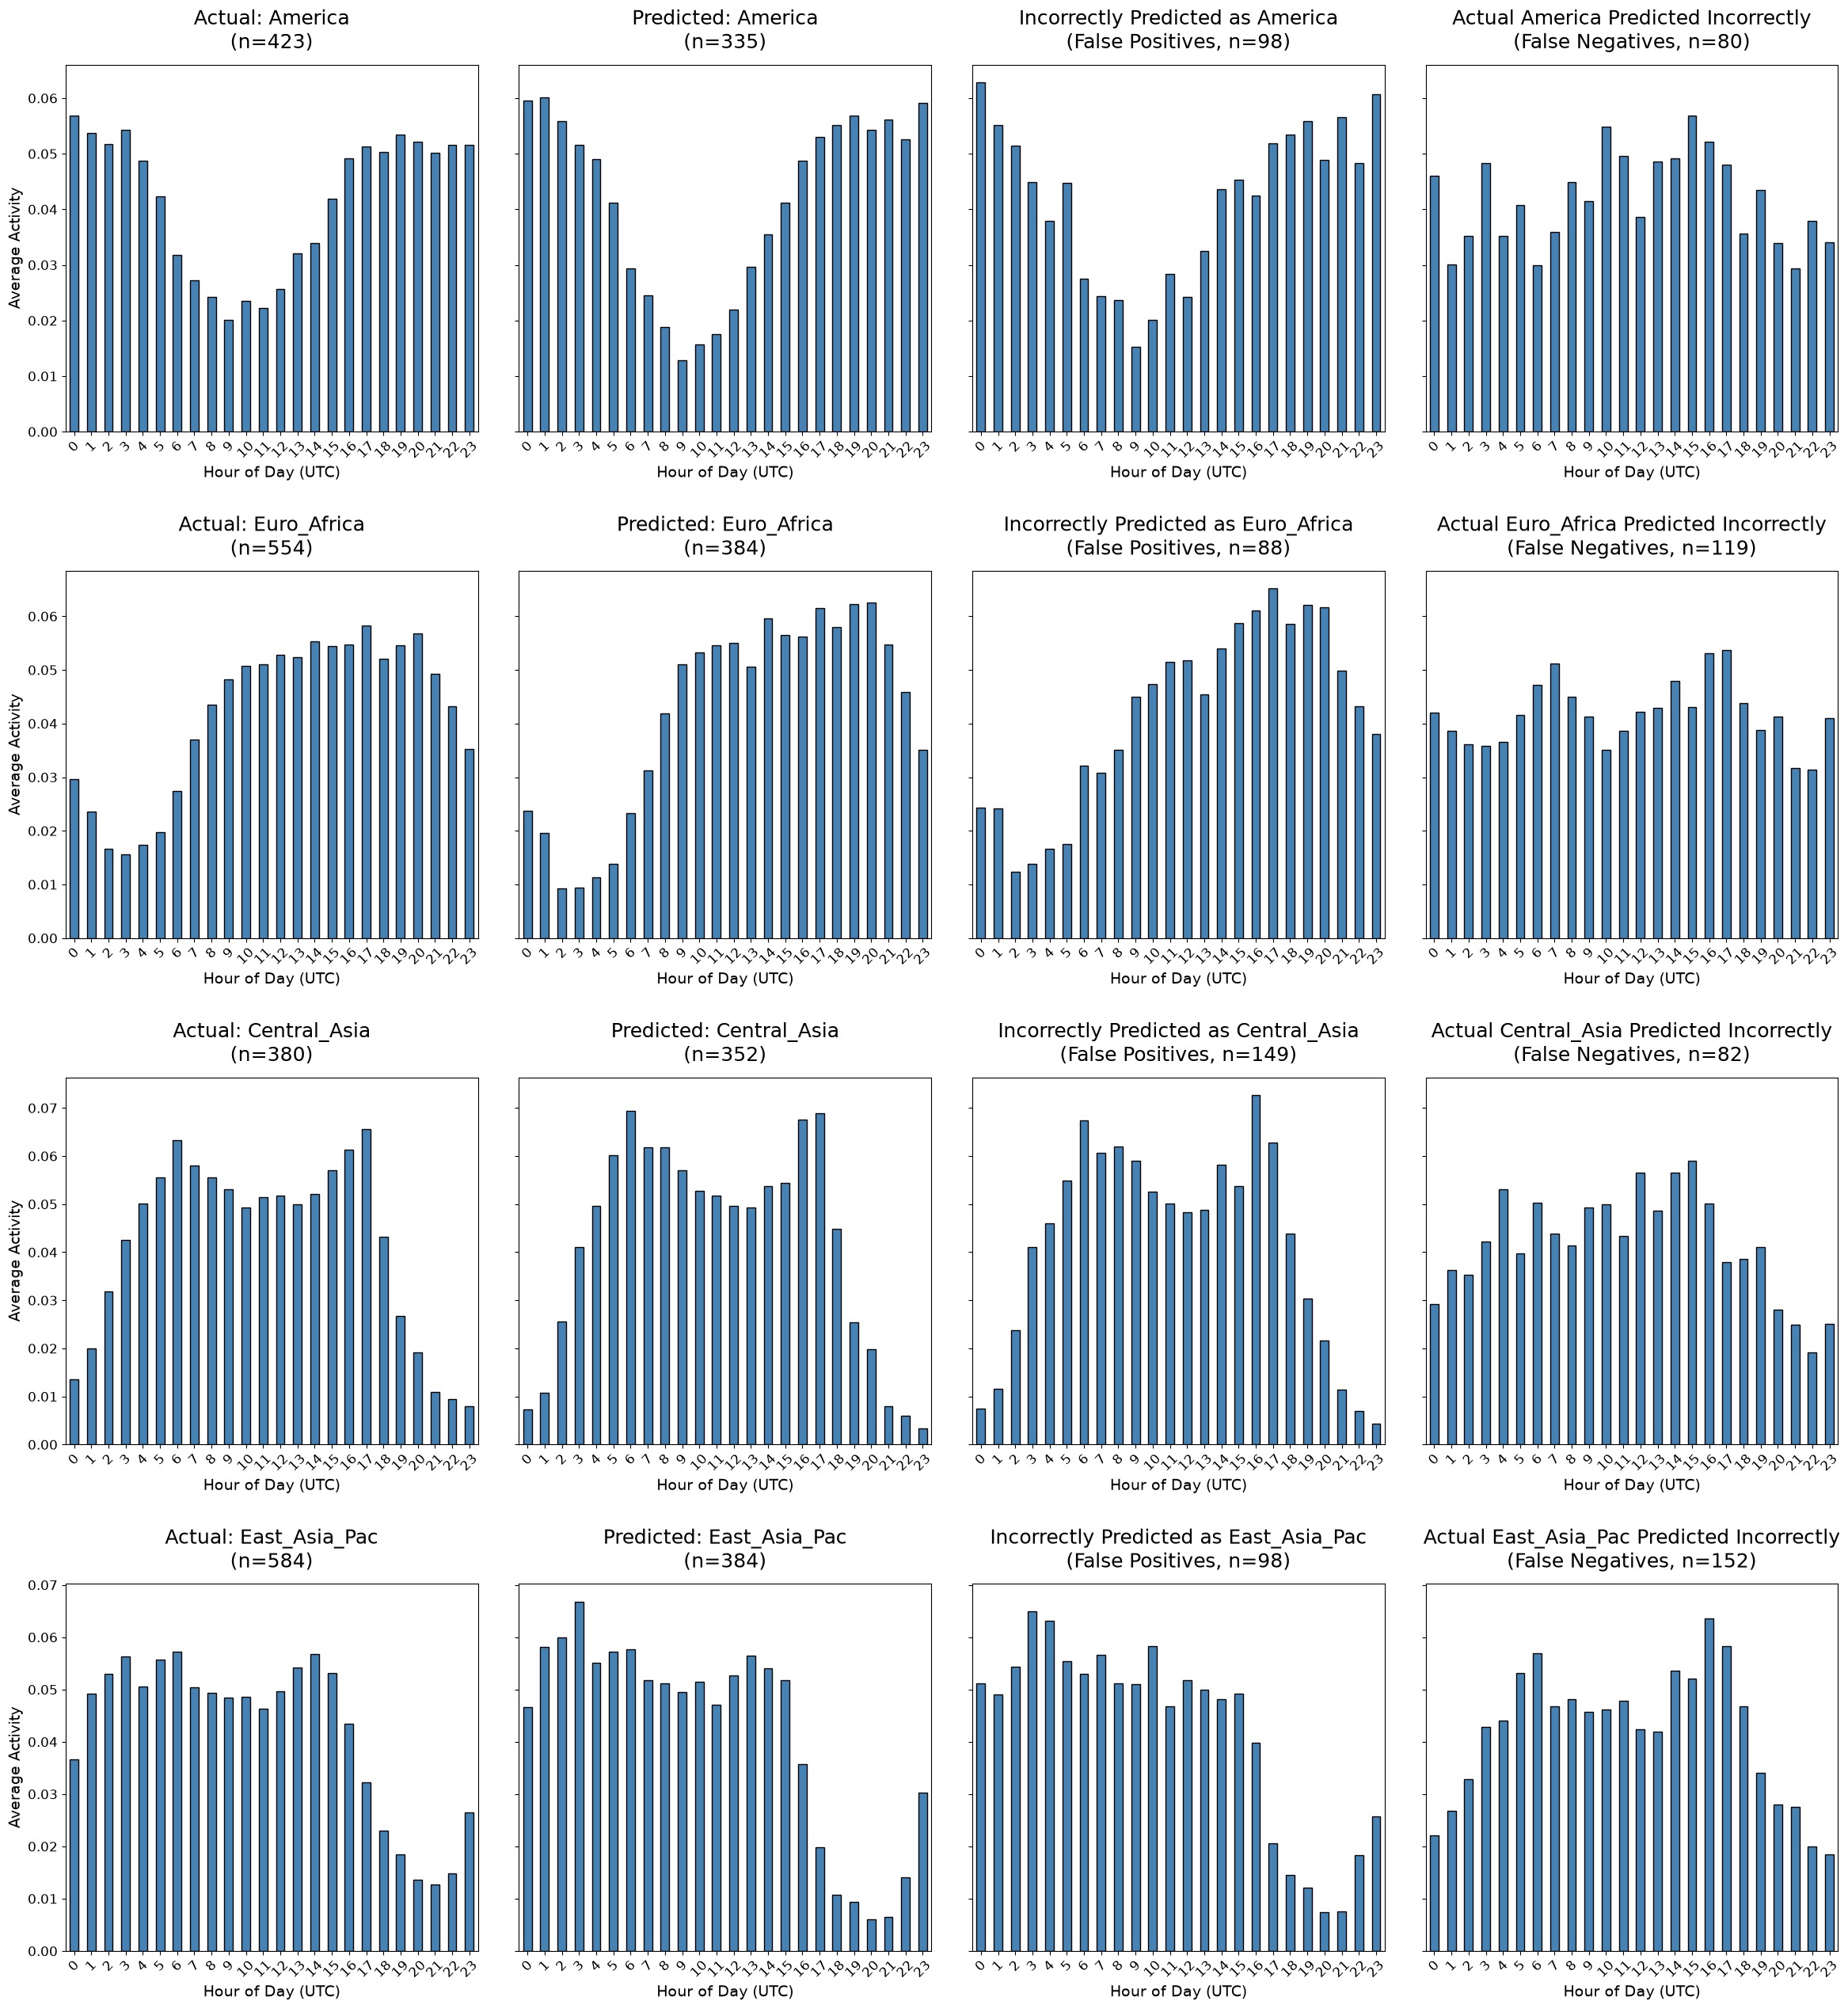

In [29]:
# 1. Define standard font sizes to make everything bigger
TITLE_FONT_SIZE = 18
LABEL_FONT_SIZE = 14
TICK_FONT_SIZE = 12

target_names = ["America", "Euro_Africa", "Central_Asia", "East_Asia_Pac"]

# 2. Increased figsize slightly to accommodate the larger text
# Added sharey='row' so the Y-axis scale is identical across each row for fair comparison
fig, axes = plt.subplots(nrows=len(target_names), ncols=4, figsize=(24, 26), sharey='row')

for i, name in enumerate(target_names):
    
    # Column 1: Real classes (Actual Region)
    actual_data = graph_data[graph_data['region'] == name]
    average_per_hour_1 = actual_data[col_names].mean()
    average_per_hour_1.plot(kind='bar', color='steelblue', edgecolor='black', ax=axes[i, 0])
    axes[i, 0].set_title(f"Actual: {name}\n(n={len(actual_data)})", fontsize=TITLE_FONT_SIZE, pad=15)
    axes[i, 0].set_ylabel('Average Activity', fontsize=LABEL_FONT_SIZE) # Y-label only needed on the far left
    
    # Column 2: What the model predicted
    pred_data = graph_data_pred_train[graph_data_pred_train['pred'] == name]
    average_per_hour_2 = pred_data[col_names].mean()
    average_per_hour_2.plot(kind='bar', color='steelblue', edgecolor='black', ax=axes[i, 1])
    axes[i, 1].set_title(f"Predicted: {name}\n(n={len(pred_data)})", fontsize=TITLE_FONT_SIZE, pad=15)
    
    # Column 3: Predicted but wrong (False Positives)
    false_pos_data = graph_data_pred_train[(graph_data_pred_train['pred'] == name) & (graph_data_pred_train['region'] != graph_data_pred_train['pred'])]
    average_per_hour_3 = false_pos_data[col_names].mean()
    average_per_hour_3.plot(kind='bar', color='steelblue', edgecolor='black', ax=axes[i, 2])
    axes[i, 2].set_title(f"Incorrectly Predicted as {name}\n(False Positives, n={len(false_pos_data)})", fontsize=TITLE_FONT_SIZE, pad=15)
    
    # Column 4: Real classes wrongly predicted (False Negatives)
    false_neg_data = graph_data_pred_train[(graph_data_pred_train['region'] == name) & (graph_data_pred_train['region'] != graph_data_pred_train['pred'])]
    average_per_hour_4 = false_neg_data[col_names].mean()
    average_per_hour_4.plot(kind='bar', color='steelblue', edgecolor='black', ax=axes[i, 3])
    axes[i, 3].set_title(f"Actual {name} Predicted Incorrectly\n(False Negatives, n={len(false_neg_data)})", fontsize=TITLE_FONT_SIZE, pad=15)

    # Apply formatting to all 4 graphs in the current row
    for j in range(4):
        axes[i, j].set_xlabel('Hour of Day (UTC)', fontsize=LABEL_FONT_SIZE)
        # Increase the size of the numbers on the X and Y axes
        axes[i, j].tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
        # Rotate the X-axis numbers so they don't smash into each other
        axes[i, j].tick_params(axis='x', rotation=45)

# 3. Add padding to tight_layout so the larger titles don't get cut off
plt.tight_layout(pad=3.0)
plt.show()